In [1]:
import sys
from pathlib import Path

dynapse_path = Path.home() / "NI_project" / "dynap-se1"
sys.path.append(str(dynapse_path))

In [2]:

import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1

import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator

import params
from params import set_params

import time
from IPython.display import Image
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

from tools.spikegen_tools import get_instantaneous_activity
from tools.spikegen_tools import generate_regular_rate_spiketrain


In [3]:
model, _ = ut.open_dynapse1()

[0]:  Bus 1 Device 2 Dynapse1DevKit serial_number 00000033
0 Dynapse1Wrapper created! libcaer init...
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.
Selected device: 00000033
Sender port: tcp://0.0.0.0:54595
Receiver port: tcp://0.0.0.0:36309
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2


### Initialize Dynap-SE

In [4]:
api = model.get_dynapse1_api()          # get Dynapse1 api from the model
set_params(model)                       # set standard parameters

config       = model.get_configuration() 

param_group0 = config.chips[0].cores[0].parameter_group 
param_group1 = config.chips[0].cores[1].parameter_group 
param_group2 = config.chips[0].cores[2].parameter_group 
param_group3 = config.chips[0].cores[3].parameter_group 

### **Set Neuron/Dendrite Parameters**

In [5]:
"""Populations on Core : S, I"""

# set AMPA (fast excitatory) weight 
param_group0.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 110
param_group0.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group0.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 90    
param_group0.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group0.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100
param_group0.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group0.param_map['PS_WEIGHT_INH_F_N'].fine_value =  70      
param_group0.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5


# set AMPA (fast exc) tau 
param_group0.param_map['NPDPIE_TAU_F_P'].fine_value   = 30      # 50
param_group0.param_map['NPDPIE_TAU_F_P'].coarse_value = 2

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group0.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group0.param_map['NPDPIE_TAU_S_P'].coarse_value = 5

# set GABA A (fast inhibitory) tau                              
param_group0.param_map['NPDPII_TAU_F_P'].fine_value = 40
param_group0.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group0.param_map['NPDPII_TAU_S_P'].fine_value = 35
param_group0.param_map['NPDPII_TAU_S_P'].coarse_value = 4


# Neuron membrane voltage gain
param_group0.param_map['IF_THR_N'].fine_value = 100
param_group0.param_map['IF_THR_N'].coarse_value = 5

# Refactory period (Base 4, 128?)
param_group0.param_map['IF_RFR_N'].fine_value = 40
param_group0.param_map['IF_RFR_N'].coarse_value = 3

# Bias Current 
param_group0.param_map['IF_DC_P'].fine_value = 20
param_group0.param_map['IF_DC_P'].coarse_value = 0



In [6]:
"""Populations on Core : SpikeGens"""

# set AMPA (fast excitatory) weight 
param_group1.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 120     #100
param_group1.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group1.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 80    #before 70nottoday
param_group1.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group1.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100
param_group1.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group1.param_map['PS_WEIGHT_INH_F_N'].fine_value =  65      #100
param_group1.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5



# set AMPA (fast exc) tau 
param_group1.param_map['NPDPIE_TAU_F_P'].fine_value   = 40    #30
param_group1.param_map['NPDPIE_TAU_F_P'].coarse_value = 3

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group1.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group1.param_map['NPDPIE_TAU_S_P'].coarse_value = 5



# set GABA A (fast inhibitory) tau                              #added this
param_group1.param_map['NPDPII_TAU_F_P'].fine_value = 60
param_group1.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group1.param_map['NPDPII_TAU_S_P'].fine_value = 50
param_group1.param_map['NPDPII_TAU_S_P'].coarse_value = 4



# Neuron membrane voltage gain
param_group1.param_map['IF_THR_N'].fine_value = 100
param_group1.param_map['IF_THR_N'].coarse_value = 5

# Refactory period (Base 4, 128?)
param_group1.param_map['IF_RFR_N'].fine_value = 80
param_group1.param_map['IF_RFR_N'].coarse_value = 2

# Bias Current 
param_group1.param_map['IF_DC_P'].fine_value = 0
param_group1.param_map['IF_DC_P'].coarse_value = 0


In [7]:
"""Populations on Core : T """

# set AMPA (fast excitatory) weight 
param_group2.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 150
param_group2.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group2.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 100    #before 70
param_group2.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group2.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100
param_group2.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group2.param_map['PS_WEIGHT_INH_F_N'].fine_value =  65      #100
param_group2.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5



# set AMPA (fast exc) tau 
param_group2.param_map['NPDPIE_TAU_F_P'].fine_value   = 30   #20
param_group2.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group2.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group2.param_map['NPDPIE_TAU_S_P'].coarse_value = 5



# set GABA A (fast inhibitory) tau                              #added this
param_group2.param_map['NPDPII_TAU_F_P'].fine_value = 60
param_group2.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group2.param_map['NPDPII_TAU_S_P'].fine_value = 50
param_group2.param_map['NPDPII_TAU_S_P'].coarse_value = 4



# Neuron membrane voltage gain
param_group2.param_map['IF_THR_N'].fine_value = 50
param_group2.param_map['IF_THR_N'].coarse_value = 4

# Refactory period (Base 4, 128?)
#param_group2.param_map['IF_RFR_N'].fine_value = 10
#param_group2.param_map['IF_RFR_N'].coarse_value = 3

# Bias Current 
param_group2.param_map['IF_DC_P'].fine_value = 0
param_group2.param_map['IF_DC_P'].coarse_value = 0


In [8]:
"""Populations on Core : IIT, IIT, Sum"""

# set AMPA (fast excitatory) weight 
param_group3.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 100    #max90
param_group3.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group3.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 80    #before 70
param_group3.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group3.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100       #max120
param_group3.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group3.param_map['PS_WEIGHT_INH_F_N'].fine_value =  65      #100
param_group3.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5



# set AMPA (fast exc) tau 
param_group3.param_map['NPDPIE_TAU_F_P'].fine_value   = 30         #max10
param_group3.param_map['NPDPIE_TAU_F_P'].coarse_value = 3

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group3.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group3.param_map['NPDPIE_TAU_S_P'].coarse_value = 5



# set GABA A (fast inhibitory) tau                              #added this
param_group3.param_map['NPDPII_TAU_F_P'].fine_value = 60           #max20
param_group3.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group3.param_map['NPDPII_TAU_S_P'].fine_value = 20         #max50
param_group3.param_map['NPDPII_TAU_S_P'].coarse_value = 4       #max3



# Neuron membrane voltage gain
#param_group3.param_map['IF_THR_N'].fine_value = 90
#param_group3.param_map['IF_THR_N'].coarse_value = 5

# Refactory period (Base 4, 128?)
param_group3.param_map['IF_RFR_N'].fine_value = 60
param_group3.param_map['IF_RFR_N'].coarse_value = 4

# Bias Current 
param_group3.param_map['IF_DC_P'].fine_value = 50
param_group3.param_map['IF_DC_P'].coarse_value = 0




### **Set Network Parameters**

In [9]:

model.update_parameter_group(param_group0, 0, 0)
model.update_parameter_group(param_group1, 0, 1)
model.update_parameter_group(param_group2, 0, 2)
model.update_parameter_group(param_group3, 0, 3)

p_G_S       = 1      # spike generator to state population


In [10]:

fs          = 4             # rate estimate sampling frequency
sigma_s     = 0.01             # gaussian smoothing width in seconds
seed        = 1
rng = np.random.default_rng(seed)


net_gen = NetworkGenerator()
net_gen.clear_network()

chip_id = 0
core_spikegens = 1
core_neurons   = 2


N_pops         = 1
N_neurons      = 8
N_spikegens    = N_pops

spikegen_ids = np.arange(1, N_spikegens + 1)
spikegen_ids = [(chip_id, core_spikegens, n_id) for n_id in spikegen_ids]
spikegens    = [Neuron(chip, core, nid, True) for chip, core, nid in spikegen_ids]


### Build Network

In [11]:

N_phys = N_neurons * N_pops      
N_tot  = N_phys + N_spikegens      # total including spike gens


populations = []
neuron_ids  = []


next_neuron_id = 1
for s in range(N_pops):
    pop_ids = [(0, core_neurons, nid) for nid in range(next_neuron_id, next_neuron_id + N_neurons)]
    pop     = [Neuron(chip, core, nid) for chip, core, nid in pop_ids]

    populations.append(pop)
    neuron_ids.extend(pop_ids)

    next_neuron_id += N_neurons


# ------------------------------------------------------------
# CONNECT SPIKEGENS -> STATE POPULATIONS - DETERMINISTIC
# ------------------------------------------------------------

for j in range(N_pops):
    k = 0
    for neuron in populations[j]:
        if k < N_neurons * p_G_S:
            net_gen.add_connection(spikegens[j], neuron, dyn1.Dynapse1SynType.AMPA)
            k += 1


In [12]:
# ------------------------------------------------------------
# APPLY CONFIGURATION
# ------------------------------------------------------------
new_config = net_gen.make_dynapse1_configuration()
model.apply_configuration(new_config)

# set_params(model, param_group=param_group0) # TODO

# ------------------------------------------------------------
# PREPARE POISSON INPUT
# ------------------------------------------------------------
global_gen_ids = ut.get_global_id_list(spikegen_ids)
poisson_gen            = model.get_poisson_gen()
poisson_gen.set_chip_id(0)

# set initial rates to zero
for gid in global_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, 0)

# ------------------------------------------------------------
# MONITOR NEURONS
# ------------------------------------------------------------

monitored_neurons = (neuron_ids)

graph, filter_node, sink_node = ut.create_neuron_select_graph(
    model,
    monitored_neurons
)

graph.start()

# clear buffer
sink_node.get_events()
api.reset_timestamp()

New configuration applied to DYNAP-SE1!


### **Run Simulation**

In [13]:
# ------------------------------------------------------------
# CONSTANT INPUT FREQUENCY SWEEP
# ------------------------------------------------------------

dt_stim = 1.0      # stimulation duration [s]
rec_time = 1.0     # recording length [s]
relax_time = 0.5   # relaxation time after stimulus [s]

rate_min  = 5      # Hz
rate_max  = 500    # Hz
rate_step = 20     # Hz

probe_rates = np.arange(rate_min, rate_max, rate_step)
print(probe_rates)

recorded_events = []

fpga_spike_gen = model.get_fpga_spike_gen()

# ------------------------------------------------------------
# LOOP OVER INPUT RATES
# ------------------------------------------------------------

for input_rate in probe_rates:

    print(f"Input rate: {input_rate} Hz")

    # ------------------------------------------------------------
    # CREATE POISSON SPIKE TIMES
    # ------------------------------------------------------------

    spike_times  = []
    indices      = []
    target_chips = []

    for gen_id in global_gen_ids:

        n_spikes = np.random.poisson(input_rate * dt_stim)

        times = np.sort(np.random.rand(n_spikes) * dt_stim)

        spike_times.extend(times)
        indices.extend([gen_id] * n_spikes)
        target_chips.extend([0] * n_spikes)

    # ------------------------------------------------------------
    # SORT SPIKES GLOBALLY IN TIME
    # ------------------------------------------------------------

    spike_times  = np.array(spike_times)
    indices      = np.array(indices)
    target_chips = np.array(target_chips)

    sort_idx = np.argsort(spike_times)

    spike_times  = spike_times[sort_idx]
    indices      = indices[sort_idx]
    target_chips = target_chips[sort_idx]

    # ------------------------------------------------------------
    # LOAD STIMULUS
    # ------------------------------------------------------------

    fpga_spike_gen.stop()

    ut.set_fpga_spike_gen(
        fpga_spike_gen = fpga_spike_gen,
        spike_times    = spike_times,
        indices        = indices,
        target_chips   = target_chips,
        isi_base       = 900,
        repeat_mode    = False
    )

    # ------------------------------------------------------------
    # RELAX NEURONS
    # ------------------------------------------------------------

    
    for gid in global_gen_ids:
        poisson_gen.write_poisson_rate_hz(gid, 0)
    
    time.sleep(relax_time)


    # ------------------------------------------------------------
    # RUN STIMULUS AND RECORD EVENTS
    # ------------------------------------------------------------

    sink_node.get_events()      # clear old events

    fpga_spike_gen.start()
    time.sleep(rec_time)
    fpga_spike_gen.stop()

    events = sink_node.get_events()

    recorded_events.append({
        "input_rate": input_rate,
        "events": events,
    })

    print(f"{len(events)} events recorded.")

[  5  25  45  65  85 105 125 145 165 185 205 225 245 265 285 305 325 345
 365 385 405 425 445 465 485]
Input rate: 5 Hz
FpgaSpikeGen already off!
RepeatMode already 0
0 events recorded.
Input rate: 25 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
3 events recorded.
Input rate: 45 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
4 events recorded.
Input rate: 65 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
6 events recorded.
Input rate: 85 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
12 events recorded.
Input rate: 105 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
11 events recorded.
Input rate: 125 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
13 events recorded.
Input rate: 145 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
16 events recorded.
Input rate: 165 Hz
FpgaSpikeGen alrea

### **Post Simulation Processing**

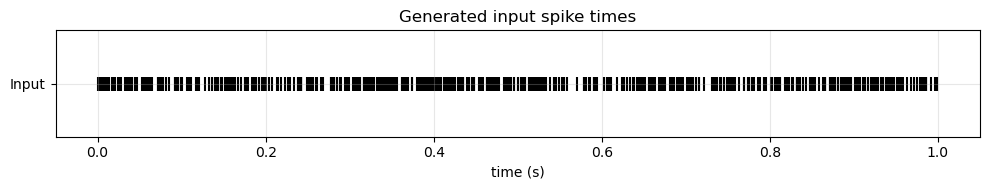

In [14]:

fig, ax = plt.subplots(figsize=(10, 2))

ax.scatter(
    spike_times,
    -1 * np.ones_like(spike_times),
    marker='|',
    s=100,
    color='black'
)

ax.set_xlabel('time (s)')
ax.set_yticks([-1])
ax.set_yticklabels(['Input'])
ax.set_title('Generated input spike times')
ax.set_xlim(-0.05, dt_stim + 0.05)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:

coarse = config.chips[0].cores[core_neurons].parameter_group.param_map['NPDPIE_TAU_F_P'].coarse_value
fine   = config.chips[0].cores[core_neurons].parameter_group.param_map['NPDPIE_TAU_F_P'].fine_value

param_val = ut._bias_as_idx(((coarse,fine)),'tuple')
print(param_val)

896


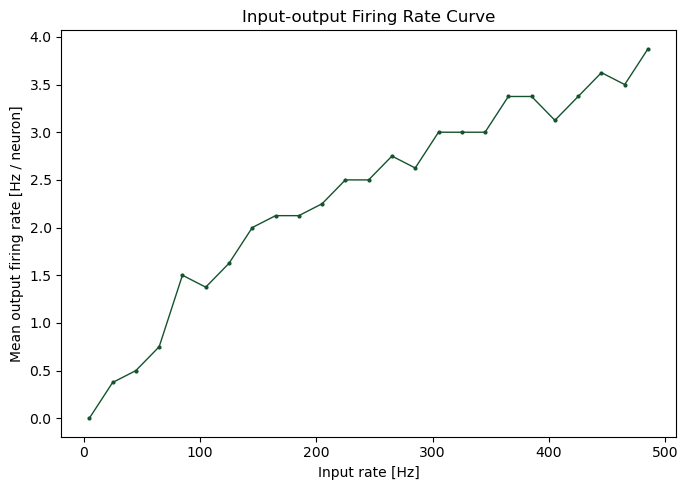

In [16]:
# ------------------------------------------------------------
# PLOT INPUT RATE VS OUTPUT FIRING RATE
# ------------------------------------------------------------

input_rates  = []
output_rates = []

for data in recorded_events:

    input_rate = data["input_rate"]
    events     = data["events"]

    n_events = len(events)

    output_rate = n_events / (rec_time * N_neurons)   # Hz, total output event rate

    input_rates.append(input_rate)
    output_rates.append(output_rate)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    input_rates,
    output_rates,
    marker    = "o",
    markersize = 2,
    linewidth = 1,
    color     = "#14532d", 
    label     = f"param = {param_val}"
)


plt.xlabel("Input rate [Hz]")
plt.ylabel("Mean output firing rate [Hz / neuron]")
plt.title("Input-output Firing Rate Curve")

plt.tight_layout()
plt.show()

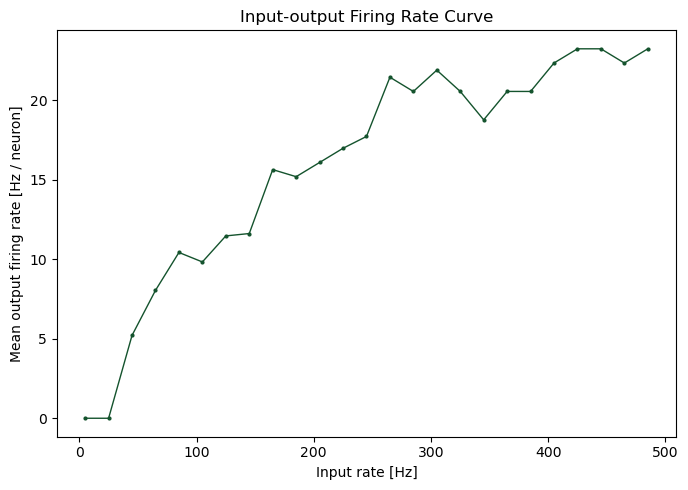

In [32]:

# ------------------------------------------------------------
# INSTANTANEOUS POPULATION ACTIVITY
# ------------------------------------------------------------
activity_dt_s = 0.15
exp_tc_s      = 0.02


def population_activity(t_spikes, n_neurons):
    t_spikes = np.asarray(t_spikes, dtype=float)
    t_spikes = np.sort(t_spikes[(t_spikes >= 0) & (t_spikes < rec_time)])

    if len(t_spikes) == 0:
        activity_x    = np.arange(0, rec_time, activity_dt_s)
        activity_rate = np.zeros_like(activity_x)
        return activity_rate, activity_x

    activity_hz, activity_x = get_instantaneous_activity(
        t_spikes,
        activity_dt_s,
        exp_tc_s
    )

    activity_hz = np.asarray(activity_hz, dtype=float)
    activity_x  = np.asarray(activity_x, dtype=float)

    mask = activity_x < rec_time

    activity_rate = activity_hz[mask] / n_neurons
    activity_x    = activity_x[mask]

    return activity_rate, activity_x

# ------------------------------------------------------------
# PLOT INPUT RATE VS OUTPUT FIRING RATE
# USING POPULATION ACTIVITY
# ------------------------------------------------------------

input_rates  = []
output_rates = []

for data in recorded_events:

    input_rate = data["input_rate"]
    events     = data["events"]

    # ------------------------------------------------------------
    # EXTRACT SPIKE TIMES
    # ------------------------------------------------------------

    spike_t = []

    for evt in events:
        spike_t.append(evt.timestamp * 1e-6)

    spike_t = np.array(spike_t)

    # shift time so recording starts at t = 0
    if len(spike_t) > 0:
        spike_t = spike_t - spike_t.min()

    # ------------------------------------------------------------
    # COMPUTE POPULATION ACTIVITY
    # ------------------------------------------------------------

    activity_rate, activity_x = population_activity(
        t_spikes  = spike_t,
        n_neurons = N_neurons
    )

    # mean output firing rate over time
    output_rate = np.mean(activity_rate)

    input_rates.append(input_rate)
    output_rates.append(output_rate)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    input_rates,
    output_rates,
    marker     = "o",
    markersize = 2,
    linewidth  = 1,
    color      = "#14532d",
)

plt.xlabel("Input rate [Hz]")
plt.ylabel("Mean output firing rate [Hz / neuron]")
plt.title("Input-output Firing Rate Curve")

plt.tight_layout()
plt.show()

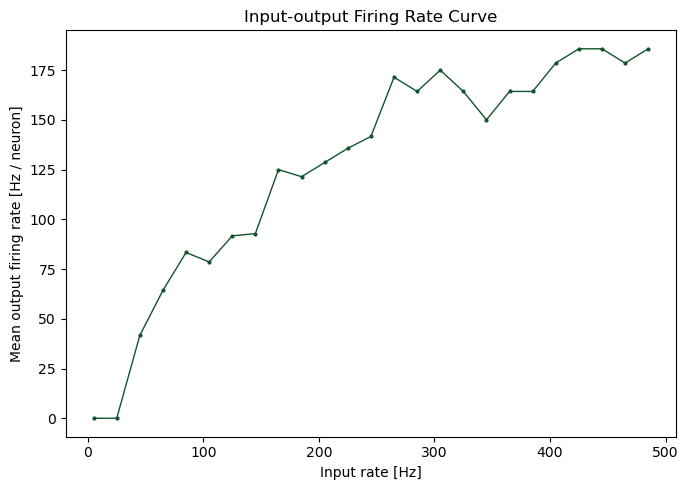

In [30]:

# ------------------------------------------------------------
# INSTANTANEOUS POPULATION ACTIVITY
# ------------------------------------------------------------
activity_dt_s = 0.15
exp_tc_s      = 0.02


def population_activity(t_spikes, n_neurons):
    t_spikes = np.asarray(t_spikes, dtype=float)
    t_spikes = np.sort(t_spikes[(t_spikes >= 0) & (t_spikes < rec_time)])

    if len(t_spikes) == 0:
        activity_x    = np.arange(0, rec_time, activity_dt_s)
        activity_rate = np.zeros_like(activity_x)
        return activity_rate, activity_x

    activity_hz, activity_x = get_instantaneous_activity(
        t_spikes,
        activity_dt_s,
        exp_tc_s
    )

    activity_hz = np.asarray(activity_hz, dtype=float)
    activity_x  = np.asarray(activity_x, dtype=float)

    mask = activity_x < rec_time

    activity_rate = activity_hz[mask]
    activity_x    = activity_x[mask]

    return activity_rate, activity_x

# ------------------------------------------------------------
# PLOT INPUT RATE VS OUTPUT FIRING RATE
# USING POPULATION ACTIVITY
# ------------------------------------------------------------

input_rates  = []
output_rates = []

for data in recorded_events:

    input_rate = data["input_rate"]
    events     = data["events"]

    # ------------------------------------------------------------
    # EXTRACT SPIKE TIMES
    # ------------------------------------------------------------

    spike_t = []

    for evt in events:
        spike_t.append(evt.timestamp * 1e-6)

    spike_t = np.array(spike_t)

    # shift time so recording starts at t = 0
    if len(spike_t) > 0:
        spike_t = spike_t - spike_t.min()

    # ------------------------------------------------------------
    # COMPUTE POPULATION ACTIVITY
    # ------------------------------------------------------------

    activity_rate, activity_x = population_activity(
        t_spikes  = spike_t,
        n_neurons = N_neurons
    )

    # mean output firing rate over time
    output_rate = np.mean(activity_rate)

    input_rates.append(input_rate)
    output_rates.append(output_rate)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    input_rates,
    output_rates,
    marker     = "o",
    markersize = 2,
    linewidth  = 1,
    color      = "#14532d",
)

plt.xlabel("Input rate [Hz]")
plt.ylabel("Mean output firing rate [Hz / neuron]")
plt.title("Input-output Firing Rate Curve")

plt.tight_layout()
plt.show()

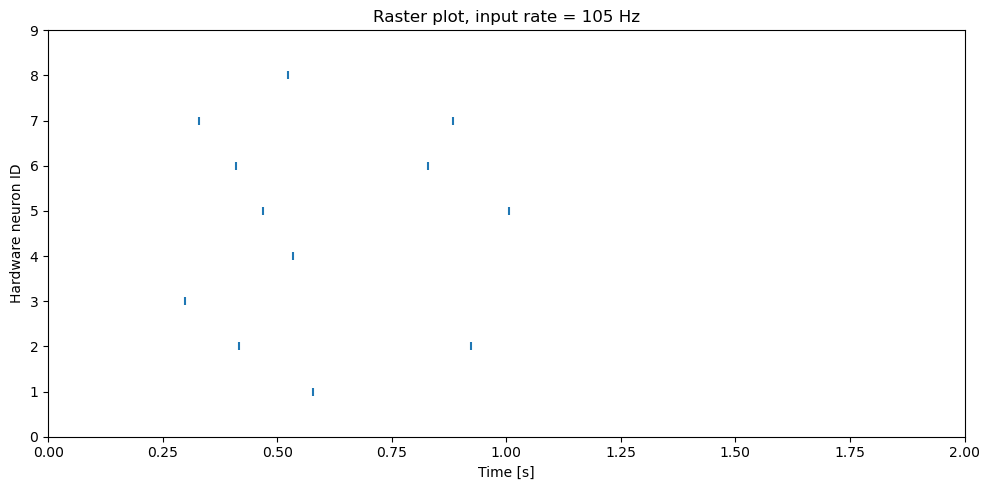

In [16]:
# ------------------------------------------------------------
# PLOT RASTER FOR ONE RECORDING INDEX
# ------------------------------------------------------------

recording_idx = 5   # 0 = first recording

recording = recorded_events[recording_idx]
plot_rate = recording["input_rate"]
events    = recording["events"]

# ------------------------------------------------------------
# EXTRACT SPIKES
# ------------------------------------------------------------

spike_t  = []
spike_id = []

for evt in events:
    spike_t.append(evt.timestamp * 1e-6)
    spike_id.append(evt.neuron_id)

spike_t  = np.array(spike_t)
spike_id = np.array(spike_id)

if len(spike_t) > 0:
    spike_t = spike_t - spike_t.min()

# ------------------------------------------------------------
# PLOT RASTER
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.scatter(
    spike_t,
    spike_id,
    marker = "|",
    s      = 40
)

plt.xlabel("Time [s]")
plt.ylabel("Hardware neuron ID")
plt.title(f"Raster plot, input rate = {plot_rate} Hz")

plt.xlim(0, rec_time + 1)

if len(spike_id) > 0:
    plt.ylim(spike_id.min() - 1, spike_id.max() + 1)

plt.tight_layout()
plt.show()

### **Parameter Sweep**

In [17]:
param_val_index = ut._bias_as_idx(((4,30)),'tuple')
print(param_val_index)

896


In [18]:
param_sweep_vals   = [int(v) for v in np.round(np.linspace(700, 900, 11))]      # AMPA Tau
# param_sweep_vals = [int(v) for v in np.round(np.linspace(800, 1500, 6))]     # AMPA W

# param_sweep_vals = [int(v) for v in np.round(np.linspace(800, 1400, 6))]     # GABA_A W
# param_sweep_vals = [int(v) for v in np.round(np.linspace(700, 1200, 6))]     # GABA_A Tau

# param_sweep_vals = [int(v) for v in np.round(np.linspace(1000, 1400, 6))]    # W GABA_B

print(f"{'index':>8} | {'coarse':>6} | {'fine':>6}")
print("-" * 29)

param_sweep_vals[2] = 742
param_sweep_vals[9] = 896

for val in param_sweep_vals:

    coarse, fine = ut._bias_as_tuple(val, "index")

    print(f"{val:8d} | {coarse:6d} | {fine:6d}")

   index | coarse |   fine
-----------------------------
     700 |      3 |     35
     720 |      3 |     55
     742 |      3 |     77
     760 |      3 |     95
     780 |      3 |    115
     800 |      3 |    135
     820 |      3 |    155
     840 |      3 |    175
     860 |      3 |    195
     896 |      3 |    231
     900 |      3 |    235


In [19]:
# ------------------------------------------------------------
# PARAMETER SWEEP + INPUT RATE SWEEP
# ------------------------------------------------------------

events_from_sweep = []

dt_stim     = 1.0      # stimulation duration [s]
rec_time    = 1.0      # recording length [s]
relax_time  = 0.5

rate_min  = 5
rate_max  = 400
rate_step = 10
n_rates = 30

# probe_rates = np.arange(rate_min, rate_max, rate_step)
probe_rates = np.geomspace(rate_min, rate_max, n_rates)
probe_rates = np.round(probe_rates).astype(int)
probe_rates = np.unique(probe_rates)


fpga_spike_gen = model.get_fpga_spike_gen()

# ------------------------------------------------------------
# LOOP OVER PARAMETER VALUES
# ------------------------------------------------------------

for param_val in param_sweep_vals:

    param_val = int(param_val)
    print(f"\nParameter value: {param_val}")

    # ------------------------------------------------------------
    # SET PARAMETER
    # ------------------------------------------------------------

    # ut.set_neuron_gain(model, chip_id=0, core_id=core_id, bias_value=param_val, bias_format='index')

    # ut.set_neuron_refractory_period(model, chip_id=0, core_id=core_id, bias_value=param_val, bias_format='index')
    # ut.set_neuron_dc(model,                chip_id=0, core_id=core_id, bias_value=param_val, bias_format='index')

    # ut.set_ampa_weight(model, chip_id=0, core_id=core_id, bias_value=param_val, bias_format='index')
    ut.set_ampa_tau(model,    chip_id=0, core_id=core_neurons, bias_value=param_val, bias_format='index')

    # ut.set_nmda_weight(model, chip_id=0, core_id=core_id, bias_value=param_val, bias_format='index')
    # ut.set_nmda_tau(model,    chip_id=0, core_id=core_id, bias_value=param_val, bias_format='index')

    # ut.set_gaba_a_tau(model, chip_id=0, core_id=core_id, bias_value=param_val, bias_format='index')

    # ut.set_gaba_b_weight(model, chip_id=0, core_id=core_id, bias_value=param_val, bias_format='index')
    # ut.set_gaba_b_tau(model,    chip_id=0, core_id=core_id, bias_value=param_val, bias_format='index')

    time.sleep(0.2)   # small settling time after changing bias

    # ------------------------------------------------------------
    # MONITOR NEURONS
    # ------------------------------------------------------------

    graph, filter_node, sink_node = ut.create_neuron_select_graph(
        model,
        monitored_neurons
    )

    graph.start()

    # ------------------------------------------------------------
    # LOOP OVER INPUT RATES
    # ------------------------------------------------------------

    for input_rate in probe_rates:

        print(f"Input rate: {input_rate} Hz")

        # ------------------------------------------------------------
        # CREATE POISSON SPIKE TIMES
        # ------------------------------------------------------------

        spike_times  = []
        indices      = []
        target_chips = []

        for gen_id in global_gen_ids:

            n_spikes = np.random.poisson(input_rate * dt_stim)

            times = np.sort(np.random.rand(n_spikes) * dt_stim)

            spike_times.extend(times)
            indices.extend([gen_id] * n_spikes)
            target_chips.extend([0] * n_spikes)

        # ------------------------------------------------------------
        # SORT SPIKES GLOBALLY IN TIME
        # ------------------------------------------------------------

        spike_times  = np.array(spike_times)
        indices      = np.array(indices)
        target_chips = np.array(target_chips)

        sort_idx = np.argsort(spike_times)

        spike_times  = spike_times[sort_idx]
        indices      = indices[sort_idx]
        target_chips = target_chips[sort_idx]

        # ------------------------------------------------------------
        # LOAD STIMULUS
        # ------------------------------------------------------------

        fpga_spike_gen.stop()

        ut.set_fpga_spike_gen(
            fpga_spike_gen = fpga_spike_gen,
            spike_times    = spike_times,
            indices        = indices,
            target_chips   = target_chips,
            isi_base       = 900,
            repeat_mode    = False
        )

        # ------------------------------------------------------------
        # RELAX NEURONS
        # ------------------------------------------------------------

        
        for gid in global_gen_ids:
            poisson_gen.write_poisson_rate_hz(gid, 0)
        
        time.sleep(relax_time)


        # ------------------------------------------------------------
        # RUN STIMULUS AND RECORD EVENTS
        # ------------------------------------------------------------

        sink_node.get_events()
        api.reset_timestamp()

        fpga_spike_gen.start()
        time.sleep(rec_time)
        fpga_spike_gen.stop()

        events = sink_node.get_events()

        print(f"{len(events)} events recorded.")

        events_from_sweep.append({
            "param_val":  param_val,
            "input_rate": input_rate,
            "events":     events,
        })

    graph.stop()


Parameter value: 700


Input rate: 5 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
5 events recorded.
Input rate: 6 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
11 events recorded.
Input rate: 7 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
5 events recorded.
Input rate: 8 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
9 events recorded.
Input rate: 9 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
11 events recorded.
Input rate: 11 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
11 events recorded.
Input rate: 12 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
15 events recorded.
Input rate: 14 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
13 events recorded.
Input rate: 17 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
15 events recorded.
Input rat

### **Post Simulation Processing**

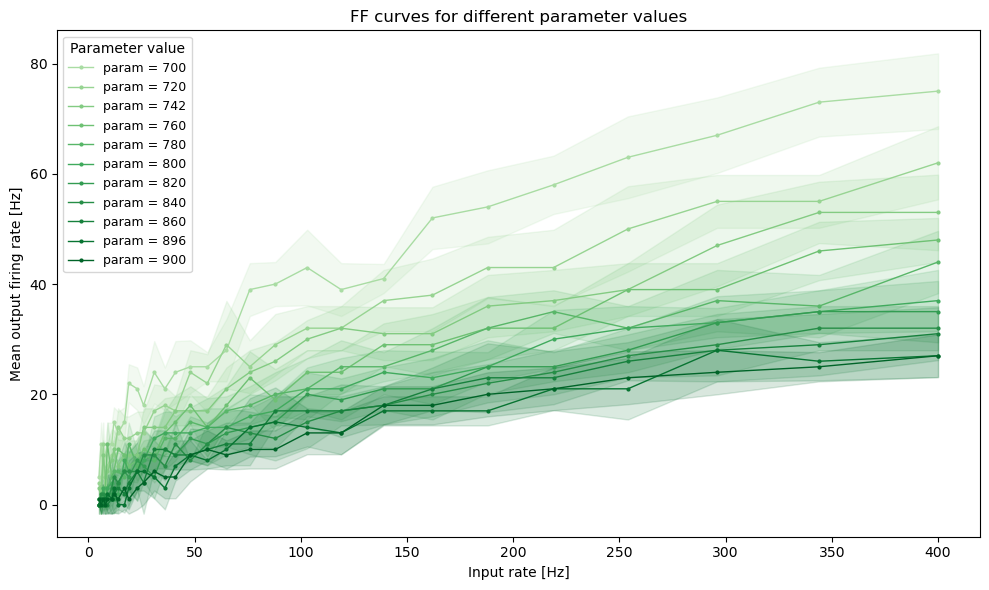

In [20]:
# ------------------------------------------------------------
# OVERLAYED FF PLOTS FOR EACH PARAMETER VALUE
# ------------------------------------------------------------

param_vals  = sorted(set(data["param_val"] for data in events_from_sweep))
input_rates = sorted(set(data["input_rate"] for data in events_from_sweep))

n_output_neurons = len(neuron_ids)

# green color shades
colors = plt.cm.Greens(np.linspace(0.35, 0.9, len(param_vals)))

plt.figure(figsize=(10, 6))

for param_val, color in zip(param_vals, colors):

    mean_y_labels = []
    std_y_labels  = []

    for input_rate in input_rates:

        matching_data = [
            data for data in events_from_sweep
            if data["param_val"] == param_val and data["input_rate"] == input_rate
        ]

        if len(matching_data) == 0:
            mean_y_labels.append(np.nan)
            std_y_labels.append(np.nan)
            continue

        events = matching_data[0]["events"]

        # ------------------------------------------------------------
        # COUNT SPIKES PER HARDWARE NEURON ID
        # ------------------------------------------------------------

        spike_ids = []

        for evt in events:
            spike_ids.append(evt.neuron_id)

        spike_ids = np.array(spike_ids)

        if len(spike_ids) > 0:
            ids, counts = np.unique(spike_ids, return_counts=True)
            rates = counts / rec_time
        else:
            rates = np.zeros(n_output_neurons)

        # ------------------------------------------------------------
        # INCLUDE SILENT NEURONS
        # ------------------------------------------------------------

        n_active_neurons = len(rates)
        n_silent_neurons = n_output_neurons - n_active_neurons

        if n_silent_neurons > 0:
            rates = np.concatenate([rates, np.zeros(n_silent_neurons)])

        mean_y_labels.append(rates.mean())
        std_y_labels.append(rates.std())

    mean_y_labels = np.array(mean_y_labels)
    std_y_labels  = np.array(std_y_labels)

    # ------------------------------------------------------------
    # PLOT ONE FF CURVE
    # ------------------------------------------------------------

    plt.plot(
        input_rates,
        N_neurons * mean_y_labels,
        marker    = "o",
        markersize = 2,
        linewidth = 1,
        color     = color,
        label     = f"param = {param_val}"
    )

    plt.fill_between(
        input_rates,
        N_neurons *  (mean_y_labels - std_y_labels),
        N_neurons * (mean_y_labels + std_y_labels),
        alpha = 0.15,
        color = color
    )

plt.xlabel("Input rate [Hz]")
plt.ylabel("Mean output firing rate [Hz]")
# plt.xscale('log')
# plt.yscale('log')
plt.title("FF curves for different parameter values")

plt.legend(
    title    = "Parameter value",
    fontsize = 9
)

plt.tight_layout()
plt.show()

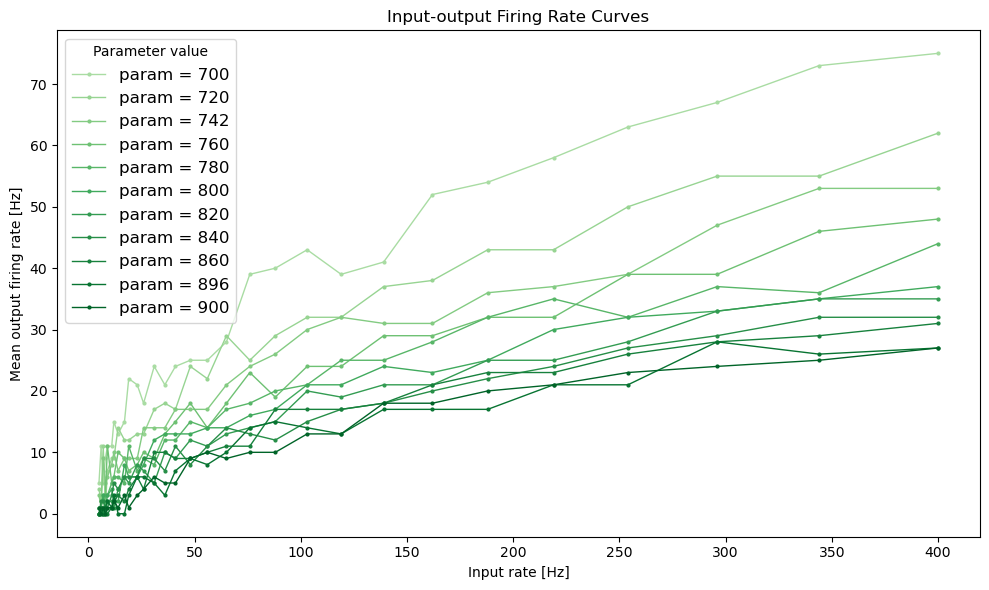

In [21]:
# ------------------------------------------------------------
# OVERLAYED FF PLOTS FOR EACH PARAMETER VALUE
# SIMPLE VERSION
# ------------------------------------------------------------

param_vals = sorted(set(data["param_val"] for data in events_from_sweep))

colors = plt.cm.Greens(np.linspace(0.35, 0.9, len(param_vals)))

plt.figure(figsize=(10, 6))

for param_val, color in zip(param_vals, colors):

    input_rates  = []
    output_rates = []

    for data in events_from_sweep:

        if data["param_val"] != param_val:
            continue

        input_rate = data["input_rate"]
        events     = data["events"]

        n_events = len(events)

        output_rate = n_events / (rec_time)

        input_rates.append(input_rate)
        output_rates.append(output_rate)

    # sort by input rate
    input_rates  = np.array(input_rates)
    output_rates = np.array(output_rates)

    sort_idx = np.argsort(input_rates)

    input_rates  = input_rates[sort_idx]
    output_rates = output_rates[sort_idx]

    # ------------------------------------------------------------
    # PLOT ONE FF CURVE
    # ------------------------------------------------------------

    plt.plot(
        input_rates,
        output_rates,
        marker     = "o",
        markersize = 2,
        linewidth  = 1,
        color      = color,
        label      = f"param = {param_val}"
    )

plt.xlabel("Input rate [Hz]")
plt.ylabel("Mean output firing rate [Hz]")
plt.title("Input-output Firing Rate Curves")

plt.legend(
    title    = "Parameter value",
    fontsize = 12
)

plt.tight_layout()
plt.show()

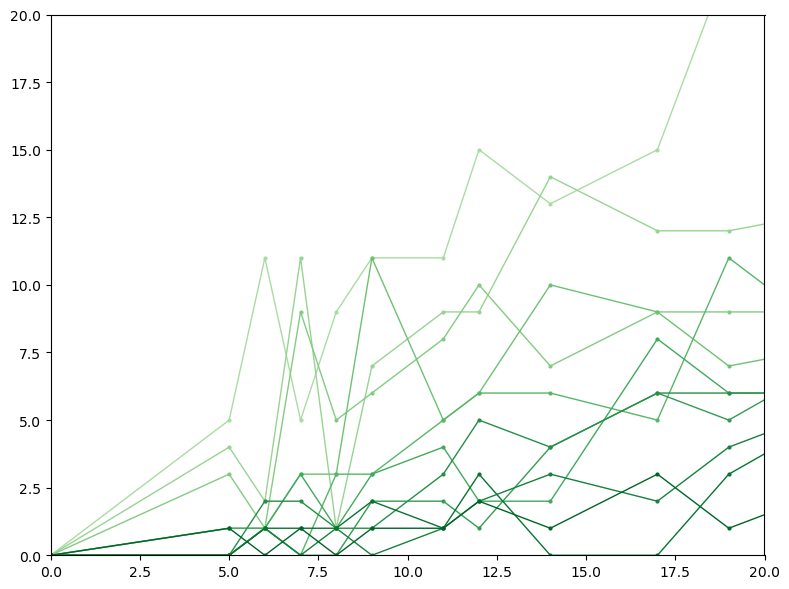

In [22]:
# ------------------------------------------------------------
# OVERLAYED FF PLOTS FOR EACH PARAMETER VALUE
# SIMPLE VERSION
# ------------------------------------------------------------

param_vals = sorted(set(data["param_val"] for data in events_from_sweep))

colors = plt.cm.Greens(np.linspace(0.35, 0.9, len(param_vals)))

plt.figure(figsize=(8, 6))

for param_val, color in zip(param_vals, colors):

    input_rates  = []
    output_rates = []

    for data in events_from_sweep:

        if data["param_val"] != param_val:
            continue

        input_rate = data["input_rate"]
        events     = data["events"]

        n_events = len(events)

        output_rate = n_events / rec_time

        input_rates.append(input_rate)
        output_rates.append(output_rate)

    # ------------------------------------------------------------
    # SORT BY INPUT RATE
    # ------------------------------------------------------------

    input_rates  = np.array(input_rates)
    output_rates = np.array(output_rates)

    sort_idx = np.argsort(input_rates)

    input_rates  = input_rates[sort_idx]
    output_rates = output_rates[sort_idx]

    # ------------------------------------------------------------
    # ADD ZERO POINT
    # ------------------------------------------------------------

    input_rates  = np.insert(input_rates,  0, 0)
    output_rates = np.insert(output_rates, 0, 0)

    # ------------------------------------------------------------
    # PLOT ONE FF CURVE
    # ------------------------------------------------------------

    plt.plot(
        input_rates,
        output_rates,
        marker     = "o",
        markersize = 2,
        linewidth  = 1,
        color      = color,
        label      = f"param = {param_val}"
    )

plt.xlim(0, 20)
plt.ylim(0, 20)


# remove axis ticks and labels

plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()
